### Decision Tree

**BUsiness Objective: Build a model that can predict a Drug to the patient on basis of their reports data(like BP,Cholestrol etc)**

### Step1:Data Gathering

In [1]:
path = r"https://raw.githubusercontent.com/kavaderohan2005-netizen/Datasets/refs/heads/main/drug200.csv"
import pandas as pd
df = pd.read_csv(path)
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


### Y: Drug


df['Drug'].value_counts()

In [3]:
df['Drug'].value_counts()

Drug
DrugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64

In [4]:
len(df)

200

In [5]:
((df['Drug'].value_counts())/len(df))*100

Drug
DrugY    45.5
drugX    27.0
drugA    11.5
drugC     8.0
drugB     8.0
Name: count, dtype: float64

<Axes: xlabel='Drug'>

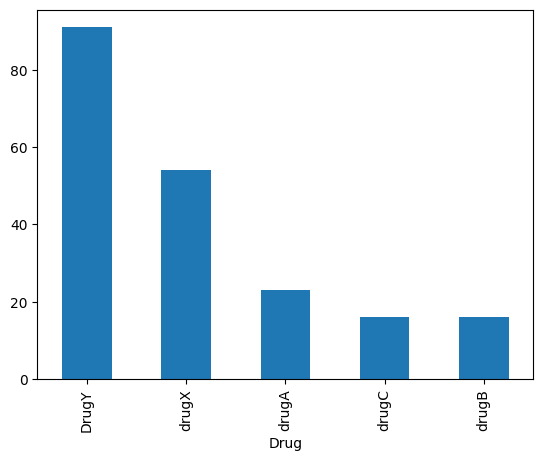

In [6]:
df['Drug'].value_counts().plot(kind='bar')

### The data appears to be imbalanced. We have to apply resampling technique

In [8]:
len(df)

200

### Separate X and Y features

Y :Drug

In [9]:
X = df.drop(columns=['Drug'])
Y = df[['Drug']]
X.head()

,Age,Sex,BP,Cholesterol,Na_to_K
0,23,F,HIGH,HIGH,25.355
1,47,M,LOW,HIGH,13.093
2,47,M,LOW,HIGH,10.114
3,28,F,NORMAL,HIGH,7.798
4,61,F,LOW,HIGH,18.043


In [10]:
Y.head()

,Drug
0,DrugY
1,drugC
2,drugC
3,drugX
4,DrugY


### Split the data into training and testing

    training: 80% 
    testing: 20%

In [24]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(X,Y,train_size=0.8,random_state=21)

### Data Preprocessing and Data Cleaning

In [25]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

cat = list(X.select_dtypes(include='object').columns) 
con = list(X.select_dtypes(include='number').columns)

num_pipe = make_pipeline(
    SimpleImputer(strategy='median'),
    MinMaxScaler()
)

cat_pipe = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore',sparse_output=False)
)

pre = ColumnTransformer([(
    "cat",cat_pipe,cat
),
("con",num_pipe,con)]).set_output(transform='pandas')
pre

,transformers,"[('cat', ...), ('con', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None


In [26]:
pre.fit(xtrain)

,transformers,"[('cat', ...), ('con', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None


In [27]:
xtrain_pre = pre.transform(xtrain) 
xtest_pre = pre.transform(xtest)

In [28]:
from imblearn.over_sampling import SMOTE


In [29]:
smote = SMOTE()
x_sampl,y_sampl = smote.fit_resample(xtrain_pre,ytrain)

In [30]:
y_sampl['Drug'].value_counts()

Drug
drugA    70
drugX    70
drugB    70
drugC    70
DrugY    70
Name: count, dtype: int64

### Decision Tree Model Building

In [31]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(criterion='gini')
model.fit(x_sampl,y_sampl)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [32]:
model.score(x_sampl,y_sampl)

1.0

In [33]:
model.score(xtest_pre,ytest)

0.95

### Evaluate the model: Confusion matrix display and Classification Report

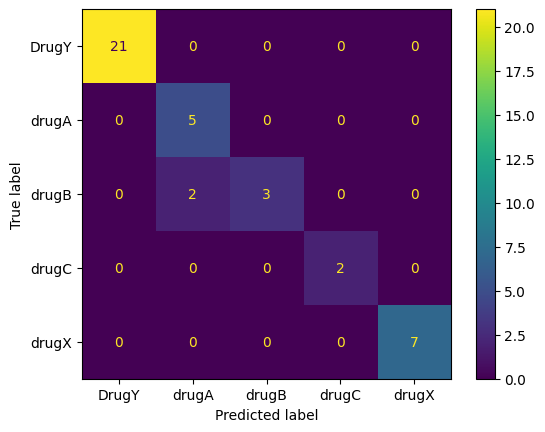

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

ConfusionMatrixDisplay.from_estimator(model,xtest_pre,ytest)

In [35]:
ypreds = model.predict(xtest_pre)
print(classification_report(ytest,ypreds))

              precision    recall  f1-score   support

       DrugY       1.00      1.00      1.00        21
       drugA       0.71      1.00      0.83         5
       drugB       1.00      0.60      0.75         5
       drugC       1.00      1.00      1.00         2
       drugX       1.00      1.00      1.00         7

    accuracy                           0.95        40
   macro avg       0.94      0.92      0.92        40
weighted avg       0.96      0.95      0.95        40

